
Ni_08-09-26
Peak   2θ (°)       ± uncertainty     Intensity       d (Å)      ± uncertainty
---------------------------------------------------------------
   1    44.4801   ±  0.0004         2872    2.03520   ± 0.00002
   2    51.8332   ±  0.0015          943    1.76245   ± 0.00005
   3    76.3915   ±  0.0039          386    1.24574   ± 0.00005
   4    92.9635   ±  0.0061          292    1.06226   ± 0.00005
   5    78.3384   ± 19.8663           33    1.21958   ± 0.25953

Ni_10-09-26
Peak   2θ (°)       ± uncertainty     Intensity       d (Å)      ± uncertainty
---------------------------------------------------------------
   1    44.4820   ±  0.0004         2529    2.03512   ± 0.00002
   2    51.8336   ±  0.0015          838    1.76244   ± 0.00005
   3    76.3901   ±  0.0041          336    1.24575   ± 0.00006
   4    92.9670   ±  0.0064          257    1.06222   ± 0.00006
   5    18.9998   ± 212.4540           31    4.66719   ± 51.70905

Ni_10-09-26_2
Peak   2θ (°)       ± uncertain

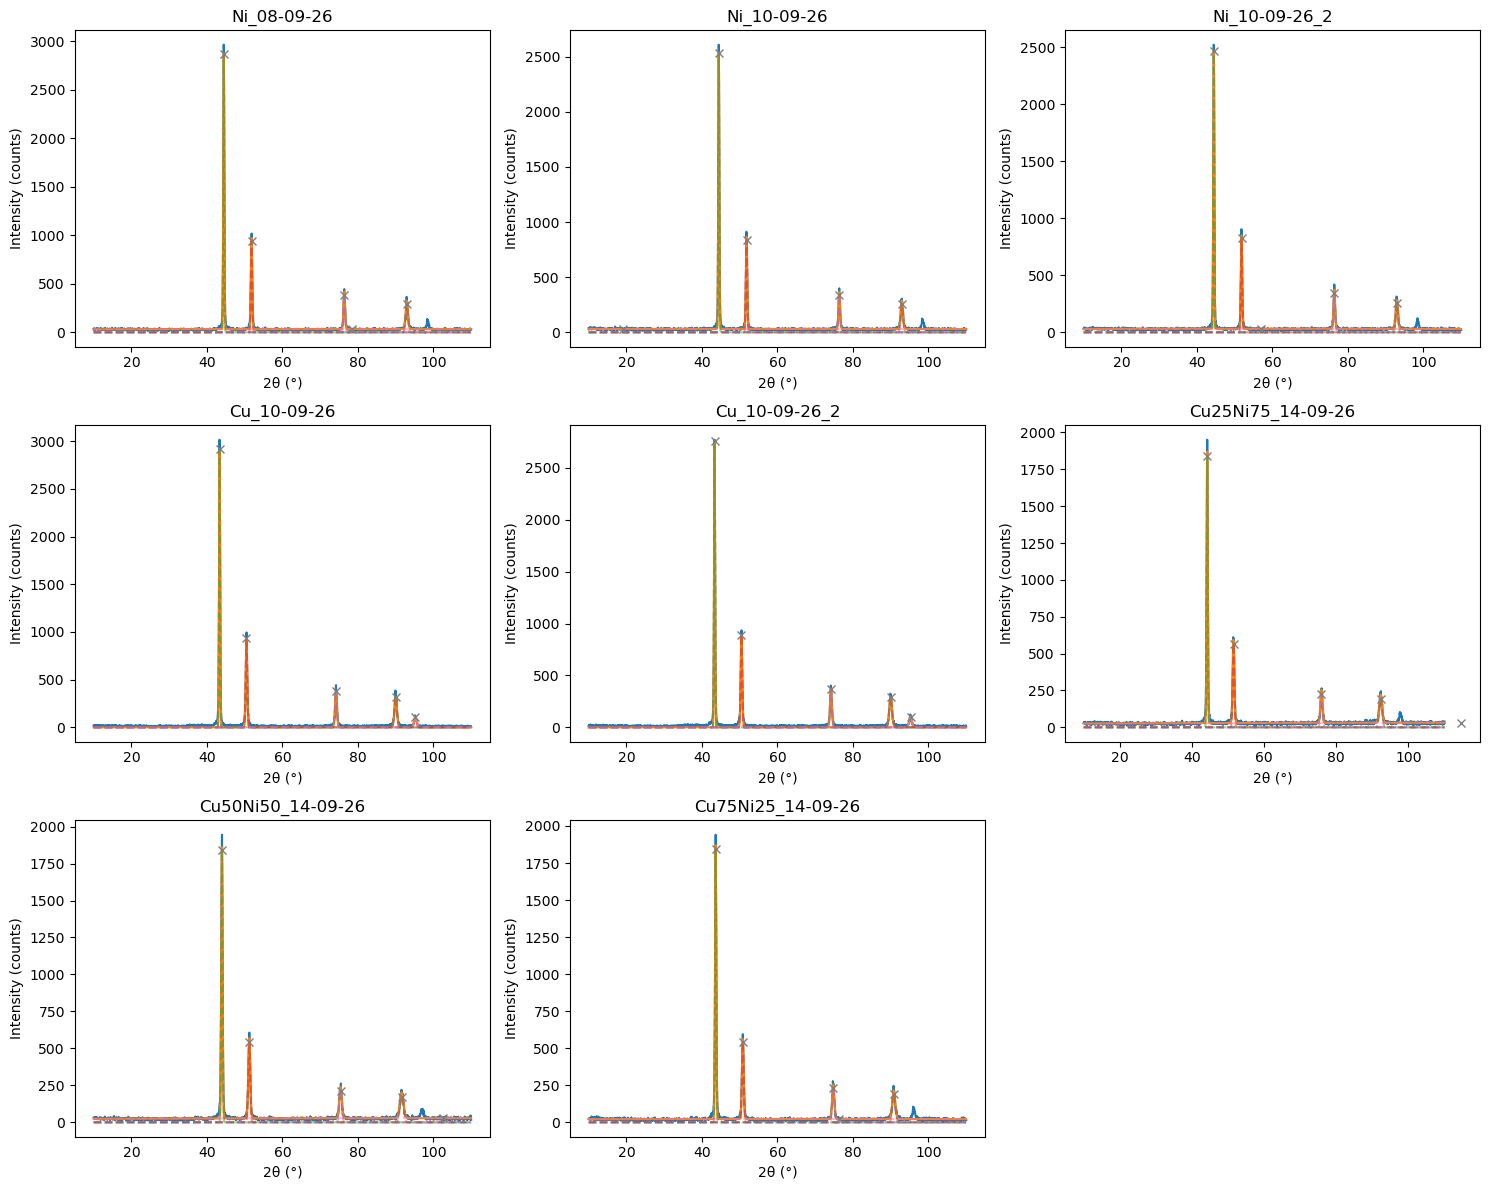

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

# List of files
files = [
    "XRD_data/Ni_08-09-26.UXD",
    "XRD_data/Ni_10-09-26.UXD",
    "XRD_data/Ni_10-09-26_2.UXD",
    "XRD_data/Cu_10-09-26.UXD",
    "XRD_data/Cu_10-09-26_2.UXD",
    "XRD_data/Cu25Ni75_14-09-26.UXD",
    "XRD_data/Cu50Ni50_14-09-26.UXD",
    "XRD_data/Cu75Ni25_14-09-26.UXD",
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

peak_angles = {}
peak_intensities = {}
peak_d = {}
peak_angle_errors = {}
peak_d_errors = {}


# ---------------------------------------------------------
# Gaussian functions
# ---------------------------------------------------------

def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))


def gaussian_sum(x, *params):

    y = np.zeros_like(x)

    # Every peak has 3 parameters:
    # amplitude, center, width
    for i in range(0, len(params), 3):

        A = params[i]
        mu = params[i + 1]
        sigma = params[i + 2]

        y += gaussian(x, A, mu, sigma)

    return y


# Bragg's law
wavelength = 1.5406  # Angstrom, Cu K_alpha
n = 1


for i, file in enumerate(files):

    # -----------------------------------------------------
    # Load data
    # -----------------------------------------------------

    data = np.loadtxt(file)

    twotheta = data[:, 0]
    intensity = data[:, 1]


    # -----------------------------------------------------
    # Step 1: Find rough peak positions
    # -----------------------------------------------------

    peaks, _ = find_peaks(intensity, prominence=50)

    rough_positions = twotheta[peaks]
    rough_heights = intensity[peaks]


    # -----------------------------------------------------
    # Step 2: Initial guesses for Gaussian fit
    # -----------------------------------------------------

    initial_guess = []

    for position, height in zip(rough_positions, rough_heights):

        initial_guess.extend([
            height,      # amplitude
            position,    # center
            0.15         # sigma (degrees)
        ])


    # -----------------------------------------------------
    # Fit sum of Gaussians
    # -----------------------------------------------------

    try:

        popt, pcov = curve_fit(
            gaussian_sum,
            twotheta,
            intensity,
            p0=initial_guess,
            maxfev=50000
        )

        # Parameter uncertainties
        perr = np.sqrt(np.diag(pcov))

        fit_success = True

    except RuntimeError:

        print("Fit failed for:", file)

        fit_success = False


    # -----------------------------------------------------
    # Store fitted peak information
    # -----------------------------------------------------

    name = file.split("/")[-1].replace(".UXD", "")

    if fit_success:

        fitted_angles = []
        fitted_intensities = []
        fitted_d = []
        fitted_angle_errors = []
        fitted_d_errors = []

        for j in range(len(rough_positions)):

            A = popt[3*j]
            mu = popt[3*j + 1]
            sigma = popt[3*j + 2]

            mu_error = perr[3*j + 1]

            # Bragg's law
            theta = np.radians(mu / 2)
            d = wavelength / (2 * np.sin(theta))

            d_error = (wavelength / (2 * np.sin(theta)**2)) * np.cos(theta) * (np.radians(mu_error) / 2)

            fitted_angles.append(mu)
            fitted_intensities.append(A)
            fitted_d.append(d)
            fitted_angle_errors.append(mu_error)
            fitted_d_errors.append(d_error)


        peak_angles[name] = np.array(fitted_angles)
        peak_intensities[name] = np.array(fitted_intensities)
        peak_d[name] = np.array(fitted_d)
        peak_angle_errors[name] = np.array(fitted_angle_errors)
        peak_d_errors[name] = np.array(fitted_d_errors)


        # -------------------------------------------------
        # Print results
        # -------------------------------------------------

        print("\n" + "=" * 75)
        print(name)
        print("=" * 75)

        print("Peak   2θ (°)       ± uncertainty     Intensity       d (Å)      ± uncertainty")
        print("---------------------------------------------------------------")

        for j in range(len(fitted_angles)):

            print(
                f"{j+1:4d}   "
                f"{fitted_angles[j]:8.4f}   "
                f"± {fitted_angle_errors[j]:7.4f}   "
                f"{fitted_intensities[j]:10.0f}   "
                f"{fitted_d[j]:8.5f}"
                f"   ± {fitted_d_errors[j]:7.5f}"
            )


        # -------------------------------------------------
        # Plot original data
        # -------------------------------------------------

        axes[i].plot(
            twotheta,
            intensity,
            label="Data"
        )


        # Plot total Gaussian fit
        fit = gaussian_sum(twotheta, *popt)

        axes[i].plot(
            twotheta,
            fit,
            label="Gaussian fit"
        )


        # Plot individual Gaussians
        for j in range(len(rough_positions)):

            A = popt[3*j]
            mu = popt[3*j + 1]
            sigma = popt[3*j + 2]

            component = gaussian(
                twotheta,
                A,
                mu,
                sigma
            )

            axes[i].plot(
                twotheta,
                component,
                "--",
                alpha=0.5
            )


        # Mark fitted centers
        axes[i].plot(
            fitted_angles,
            fitted_intensities,
            "x"
        )


    else:

        # If fit fails, just plot original data
        axes[i].plot(twotheta, intensity)


    # Labels
    axes[i].set_xlabel("2θ (°)")
    axes[i].set_ylabel("Intensity (counts)")
    axes[i].set_title(name)


# Turn off unused subplot
for i in range(len(files), len(axes)):
    axes[i].axis("off")


plt.tight_layout()
plt.show()
print()